In [1]:
using ZetaReg, CSV, DataFrames, StatsBase, Plots, SpecialFunctions, Printf

## running test 
include("./test/runtests.jl")


Initial Data from InsuranceData:
num_insurances (Z):
94, 342, 590, 433, 177, 59
6, 34, 66, 59, 30, 12
0, 5, 16, 11, 6, 8
0, 3, 8, 7, 2, 2
0, 0, 0, 3, 4, 2
0, 2, 3, 3, 0, 0
0, 0, 2, 2, 0, 0
0, 0, 1, 1, 1, 0
0, 0, 1, 0, 0, 0
0, 0, 0, 1, 0, 0
0, 0, 2, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 1, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 1, 0
0, 0, 0, 0, 0, 0

age (W):
20, 30, 40, 50, 60, 70

Comparison of Results:
Method           | β (first)   | θ (min)   | iters | log-likelihood (last)
QDE               | 4.3655     | 2.4156     | 5     | -1198.2801
ZetaMeanModel     | -1.1905    | 2.5885     | 9     | -1197.2282
ZetaMeanLogModel  | -1.9572    | 2.5514     | 9     | -1197.4561
Detailed Vectors (β and θ):
Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   
1     | 4.3655     | -1.1905         | -1.9572         || 3.8084     | 3.9200          | 3.8385         
2     | -0.0279    | 0.6953          | 0.4888          || 

Test.DefaultTestSet("ZetaReg Tests for CitiesData", Any[], 0, false, false, true, 1.737951529307108e9, 1.737951529332758e9, false, "/Users/caleblee/Codes/Julia/MyPack/ZetaReg/test/runtests.jl")

In [2]:
## calculating the loglikelihood of zeta distribution for insuarance data
Z = InsuranceData.num_insurances
W = InsuranceData.age
## MLE of Zeta distribution without covariates
Z0 = sum(Z,dims= 2)
n0 = length(Z0)
x = range(1,n0,n0) 
θ0 = Rootθ(sum(log.(x) .* Z0)/sum(Z0))
fit0 = (x.^(-θ0))./zeta(θ0) * sum(Z0)

nn1, nn2 = size(Z)          # numbers of rows and columns
z = [i for i in 1:nn1, _ in 1:nn2]
z_1 = vec(sum(Z.*log.(z), dims=1))
n_11 = vec(sum(Z, dims=1))
ZetaLogLik(θ0, z_1, n_11)
LogLik0 = ZetaLogLik(θ0,z_1,n_11)

println("θ0: ", θ0)
println("LogLik0: ", LogLik0)

θ0: 3.1518146397649573
LogLik0: -1210.7227200236296


Fitting 2010 Census Frequency Data with the Zeta Distribution:


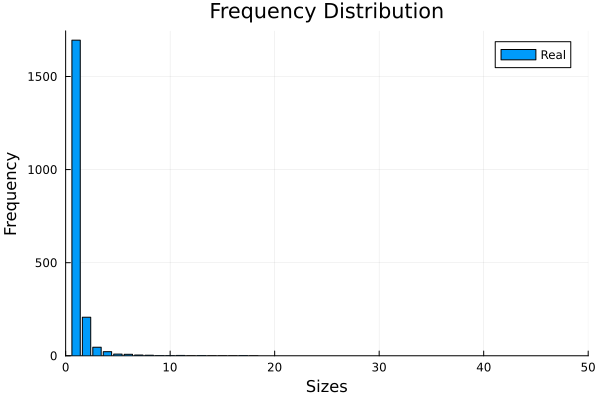

In [3]:
using ZetaReg, CSV, DataFrames, StatsBase, Plots, SpecialFunctions, Printf

# 读取 CSV 文件
df1 = CSV.read("src/datasets/census2000.csv", DataFrame)
df2 = CSV.read("src/datasets/census2010.csv", DataFrame)
df3 = CSV.read("src/datasets/census2020.csv", DataFrame)

data1 = df1
data1.CENSUS2000POP = [tryparse(Int, s) for s in data1.CENSUS2000POP]
data1 = filter(row -> row.SUMLEV .== 50 && row.CENSUS2000POP !== nothing, data1)
data1 = select(data1, [:STATE, :CENSUS2000POP])

data2 = df2
data2.CENSUS2010POP = [tryparse(Float64, String(x)) for x in data2.CENSUS2010POP]
data2 = filter(row -> row.SUMLEV .== 50 && row.CENSUS2010POP !== nothing, data2)
data2 = select(data2, [:STATE, :CENSUS2010POP])

data3 = df3
# data3.ESTIMATESBASE2020 = [tryparse(Float64, Int(x)) for x in data3.ESTIMATESBASE2020]
data3 = filter(row -> row.SUMLEV .== 50 , data3)
data3 = select(data3, [:STATE, :ESTIMATESBASE2020])

# 使用 data2 作为示例数据
data = copy(data2)

# 使用 cut 函数划分区间
size1 = 8e4
data[:,2] = ceil.(data[:,2]./size1)

# using DataFrames
state_data = DataFrame(
    STATE = [1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 
             24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 
             42, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56],
    STNAME = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", 
              "Connecticut", "Delaware", "District of Columbia", "Florida", "Georgia", 
              "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", 
              "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", 
              "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", 
              "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", 
              "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", 
              "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", 
              "Washington", "West Virginia", "Wisconsin", "Wyoming"],
    Region = [
        "South", "West", "West", "South", "West", "West", "Northeast", "South", "South",
        "South", "South", "West", "West", "Midwest", "Midwest", "Midwest", "Midwest", "South",
        "South", "Northeast", "South", "Northeast", "Midwest", "Midwest", "South", "Midwest",
        "West", "Midwest", "West", "Northeast", "Northeast", "West", "Northeast", "South",
        "Midwest", "Midwest", "South", "West", "Northeast", "Northeast", "South", "Midwest",
        "South", "South", "West", "Northeast", "South", "West", "South", "Midwest", "West"
    ],
    Division = [
        "East South Central", "Pacific", "Mountain", "West South Central", "Pacific", "Mountain", 
        "New England", "South Atlantic", "South Atlantic", "South Atlantic", "South Atlantic", 
        "Pacific", "Mountain", "East North Central", "East North Central", "West North Central", 
        "West North Central", "East South Central", "West South Central", "New England", 
        "South Atlantic", "New England", "East North Central", "West North Central", 
        "East South Central", "West North Central", "Mountain", "West North Central", 
        "Mountain", "New England", "Middle Atlantic", "Mountain", "Middle Atlantic", 
        "South Atlantic", "West North Central", "East North Central", "West South Central", 
        "Pacific", "Middle Atlantic", "New England", "South Atlantic", "West North Central", 
        "East South Central", "West South Central", "Mountain", "New England", "South Atlantic", 
        "Pacific", "South Atlantic", "East North Central", "Mountain"
    ]
)

# 定义 Division 的数字编码规则
division_mapping = Dict(
    "New England" => 1,
    "Middle Atlantic" => 2,
    "East North Central" => 3,
    "West North Central" => 4,
    "South Atlantic" => 5,
    "East South Central" => 6,
    "West South Central" => 7,
    "Mountain" => 8,
    "Pacific" => 9
)
# 将 Division 列转换为数字
state_data.DivisionCode = [division_mapping[d] for d in state_data.Division]

# 打印 InsuranceData 数据
println("Fitting 2010 Census Frequency Data with the Zeta Distribution:")
println("==============================================")

# display the hisogram
p = plot()
bar!(p, sum(Z,dims= 2), ylim = (0,sum(Z,dims= 2)[1]+50), bins=size(Z)[1], xlim=(0, 50), label = "Real" , xlabel="Sizes", ylabel="Frequency", title="Frequency Distribution")
display(p)


Fitting 2010 Census Frequency Data with the Zeta Distribution:
There exists at least a non-real or NaN value. Stopping execution.
θ0: 1.8964418539880978
LogLik0: -9739.231038424308
LogLik1: -9629.649280626167
LogLik2: -9600.89265972763
LogLik3: -9327.369046440694


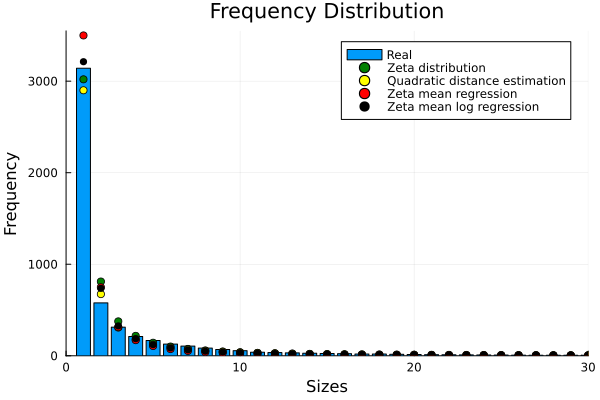

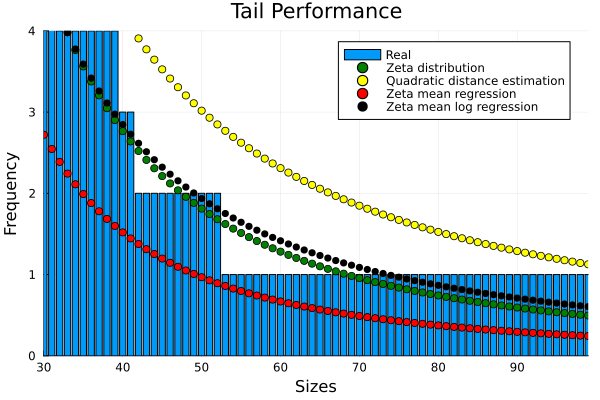

"/Users/caleblee/Desktop/skill summit time/2022年论文 正在写/Zeta mean log reg/fittedTail.pdf"

In [4]:
# 使用 data2 作为示例数据
data = copy(data2)
data.DivisionCode = [state_data[findall(state_data.STATE .== d),4][1] for d in data.STATE]

# 使用 cut 函数划分区间
size1 = 1e5
data[:,2] = ceil.(data[:,2]./size1)

# 获取所有唯一的分类标签
categories = unique(data.STATE)
categories = unique(data.DivisionCode)
maxCens = maximum(data[:,2])
Z = zeros(Float64, Int(maxCens), length(categories))
W = zeros(Float64, length(categories), length(categories))

cat0 = 0
for cat in categories
    cat0 = cat0 + 1
    W[cat0, cat0] = 1.0
    yTra = filter(row -> row.DivisionCode .== cat , data)
#     yTra = filter(row -> row.STATE .== cat , data)
    yTra = yTra[:,2]
    for i in yTra
#         Z[Int(i),Int(cat0)] = Z[Int(i),Int(cat0)] + 1
        Z[1:Int(i),Int(cat0)] = Z[1:Int(i),Int(cat0)] .+ 1
    end
end

# 打印 InsuranceData 数据
println("Fitting 2010 Census Frequency Data with the Zeta Distribution:")
println("==============================================")

## MLE of Zeta distribution without covariates
Z0 = sum(Z,dims= 2)
n0 = length(Z0)
x = range(1,n0,n0) 
θ0 = Rootθ(sum(log.(x) .* Z0)/sum(Z0))
fit0 = (x.^(-θ0))./zeta(θ0) * sum(Z0)

nn1, nn2 = size(Z)          # numbers of rows and columns
z = [i for i in 1:nn1, _ in 1:nn2]
z_1 = vec(sum(Z.*log.(z), dims=1))
n_11 = vec(sum(Z, dims=1))
ZetaLogLik(θ0, z_1, n_11)
LogLik0 = ZetaLogLik(θ0,z_1,n_11)

## MLEs of Zeta regression models
(rho1, θ1, iters1, loglikelihoods1) = QDE(Z, W)
(rho2, θ2, iters2, loglikelihoods2) = ZetaMeanModel(Z, W)
(rho3, θ3, iters3, loglikelihoods3) = ZetaMeanLogModel(Z, W)


println("θ0: ", θ0)
println("LogLik0: ", LogLik0)
println("LogLik1: ", loglikelihoods1[end])
println("LogLik2: ", loglikelihoods2[end])
println("LogLik3: ", loglikelihoods3[end])


N = sum(Z,dims=1)
n1 = length(N)
x1 = range(1,n0,n0) 
fit2 = zeros(n0)
fit1 = zeros(n0)
fit3 = zeros(n0)

for l in range(1, n1, n1)
    l = Int64(l)
    theta1 = θ1[l]
    fit1 = fit1 + (x1.^(-theta1))./zeta(theta1) .* N[l]
    theta2 = θ2[l]
    fit2 = fit2 + (x1.^(-theta2))./zeta(theta2) .* N[l]
    theta3 = θ3[l]
    fit3 = fit3 + (x1.^(-theta3))./zeta(theta3) .* N[l]
end


# 绘制图形
p1 = plot()
bar!(p1, vec(Z0), ylim = (0,max(fit0[1],Z0[1],fit2[1])+50), bins=n0, xlim=(0, 30), label = "Real" , xlabel="Sizes", ylabel="Frequency", title="Frequency Distribution")
plot!(p1, x, fit0, label = "Zeta distribution", color = "green", seriestype=:scatter)
plot!(p1, x, fit1, label = "Quadratic distance estimation", color = "yellow", seriestype=:scatter)
plot!(p1, x, fit2, label = "Zeta mean regression", color = "red", seriestype=:scatter)
plot!(p1, x, fit3, label = "Zeta mean log regression", color = "black", seriestype=:scatter)

# 显示图形
display(p1)

savefig(p1,"/Users/caleblee/Desktop/skill summit time/2022年论文 正在写/Zeta mean log reg/Frequency.pdf")

# 绘制图形
p2 = plot()
bar!(p2, vec(Z0), ylim = (0,4), bins=n0, xlim=(30, n0), label = "Real" , xlabel="Sizes", ylabel="Frequency", title="Tail Performance")
plot!(p2, x, fit0, label = "Zeta distribution", color = "green", seriestype=:scatter)
plot!(p2, x, fit1, label = "Quadratic distance estimation", color = "yellow", seriestype=:scatter)
plot!(p2, x, fit2, label = "Zeta mean regression", color = "red", seriestype=:scatter)
plot!(p2, x, fit3, label = "Zeta mean log regression", color = "black", seriestype=:scatter)

# 显示图形
display(p2)
# 

savefig(p2,"/Users/caleblee/Desktop/skill summit time/2022年论文 正在写/Zeta mean log reg/fittedTail.pdf")



In [5]:

println("==============================================\n")
# 假设 Z 和 W 是已定义的矩阵
(rho1, θ1, iters1, loglikelihoods1) = QDE(Z, W)
(rho2, θ2, iters2, loglikelihoods2) = ZetaMeanModel(Z, W)
(rho3, θ3, iters3, loglikelihoods3) = ZetaMeanLogModel(Z, W)


# 打印结果
println("Comparison of Results:")
println("====================================================================")
println("Method           | β (first)   | θ (min)   | iters | log-likelihood (last)")
println("====================================================================")
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "QDE", rho1[1], minimum(θ1), iters1, loglikelihoods1[end])
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "ZetaMeanModel", rho2[1], minimum(θ2), iters2, loglikelihoods2[end])
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "ZetaMeanLogModel", rho3[1], minimum(θ3), iters3, loglikelihoods3[end])
println("====================================================================")

# 打印表头
println("Detailed Vectors (β and θ):")
println("===============================================================================================================")
println("Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   ")
println("===============================================================================================================")

# 获取最大长度，确保遍历所有向量
max_len = maximum([length(rho1), length(rho2), length(rho3), length(θ1), length(θ2), length(θ3)])

# 按行打印
for i in 1:max_len
    β_qde = i <= length(rho1) ? @sprintf("%-10.4f", rho1[i]) : " " * " "
    β_zeta_mean = i <= length(rho2) ? @sprintf("%-15.4f", rho2[i]) : " " * " "
    β_zeta_log = i <= length(rho3) ? @sprintf("%-15.4f", rho3[i]) : " " * " "
    θ_qde = i <= length(θ1) ? @sprintf("%-10.4f", θ1[i]) : " " * " "
    θ_zeta_mean = i <= length(θ2) ? @sprintf("%-15.4f", θ2[i]) : " " * " "
    θ_zeta_log = i <= length(θ3) ? @sprintf("%-15.4f", θ3[i]) : " " * " "

    println(@sprintf("%-5d | %-10s | %-15s | %-15s || %-10s | %-15s | %-15s", 
                     i, β_qde, β_zeta_mean, β_zeta_log, θ_qde, θ_zeta_mean, θ_zeta_log))
end

println("===============================================================================================================")



There exists at least a non-real or NaN value. Stopping execution.
Comparison of Results:
Method           | β (first)   | θ (min)   | iters | log-likelihood (last)
QDE               | 1.7588     | 1.2169     | 16    | -9629.6493
ZetaMeanModel     | 9.3048     | 2.0000     | 13    | -9600.8927
ZetaMeanLogModel  | -0.5722    | 1.4740     | 7     | -9327.3690
Detailed Vectors (β and θ):
Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   
1     | 1.7588     | 9.3048          | -0.5722         || 2.8943     | 2.8799          | 2.8801         
2     | 1.1355     | -3.0423         | -0.3678         || 1.2169     | 2.0000          | 1.4740         
3     | -0.5419    | 9.8600          | 0.3497          || 1.8883     | 2.0089          | 1.9485         
4     | 0.1295     | -1.3655         | 0.0305          || 1.9479     | 2.0232          | 1.9905         
5     | 0.1891     | -1.6880         | 0.0083          || 1.3733     | 2.0000        